In [1]:
from netCDF4 import Dataset
import xarray as xr
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import matplotlib.pyplot as plt

In [2]:
###Read Datasets and convert them!
#Path
latitud = '2-9'
longitud = '135-145'
path = '/Users/Casi94/Documents/PhD/Thesis/NN_real/Area_'+latitud+'_'+longitud+'_ERA5/'
#Data
sst1 = xr.open_dataset(path+'SST_fldmean.nc')
slopes = pd.read_csv(path+'Slopes_data_'+latitud+'_'+longitud+'_ERA5.csv')
TCWV = xr.open_dataset(path+'TCWV_fldmean.nc')
vertical = xr.open_dataset(path+'Verticalw_fldmean.nc')
zonal = xr.open_dataset(path+'Zonalu_fldmean.nc')
meridional = xr.open_dataset(path+'Meridionalv_fldmean.nc')
LW_clr = xr.open_dataset(path+'TOP_net_clr_LW_fldmean.nc')
LW_all = xr.open_dataset(path+'TOP_net_LW_fldmean.nc')
SW_clr = xr.open_dataset(path+'SFC_net_clr_SW_fldmean.nc')
SW_all = xr.open_dataset(path+'SFC_net_SW_fldmean.nc')

In [3]:
### Here each single level variables
time_fin = 35040 
sst = np.array(sst1.sst[0:time_fin]).flatten()
slop = np.array(slopes['Slope'])
iqr = np.array(slopes['IQR'])
tcw = np.array(TCWV.tcwv[0:time_fin]).flatten()
LWc = np.array(LW_clr.ttrc[0:time_fin]).flatten()/3600
LW = np.array(LW_all.ttr[0:time_fin]).flatten()/3600
SWc = np.array(SW_clr.ssrc[0:time_fin]).flatten()/3600
SW = np.array(SW_all.ssr[0:time_fin]).flatten()/3600
### Here each pressure levels variables
ww = np.ones((time_fin,27))
uu = np.ones((time_fin,27))
vv = np.ones((time_fin,27))
for i in range(np.shape(np.array(vertical.w))[1]):
    ww[:,i] = np.array(vertical.w[0:time_fin,i])
    uu[:,i] = np.array(zonal.u[0:time_fin,i])
    vv[:,i] = np.array(meridional.v[0:time_fin,i])


# Initial test

In [4]:
### Creating column names
columna = ['SST','IQR','TCWV','LWC','LW','SWC','SW']
for i in range(np.shape(np.array(vertical.w))[1]):
    columna.append('W'+str(i))
for i in range(np.shape(np.array(vertical.w))[1]):
    columna.append('U'+str(i))
for i in range(np.shape(np.array(vertical.w))[1]):
    columna.append('V'+str(i))

In [5]:
### Put them in a dataframe!
X = pd.DataFrame(np.column_stack((sst,iqr,tcw,LWc,LW,SWc,SW,ww,uu,vv)), columns = columna)
Y = pd.DataFrame({'Slope':slop})

In [6]:
##VIF
V = add_constant(X)
vif = pd.Series([variance_inflation_factor(V.values, i) for i in range(V.shape[1])], index=V.columns)

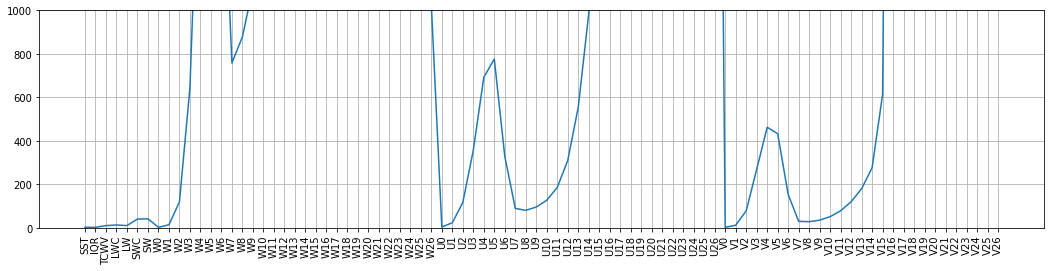

In [7]:
plt.figure(figsize = (18,4))
plt.plot(vif[1:])
plt.xticks(rotation = 90)
plt.ylim(0,1000)
plt.grid()
plt.show()

# Test 1

In [8]:
### Creating column names
columna = ['SST','IQR','TCWV','LWC','LW','SWC','SW','W0','W1','W7']
for i in range(15):
    columna.append('U'+str(i))
columna.append('U26')
for i in range(15):
    columna.append('V'+str(i))
columna.append('V26')

In [11]:
### Put them in a dataframe!
X = pd.DataFrame(np.column_stack((sst,iqr,tcw,LWc,LW,SWc,SW,ww[:,0],ww[:,1],ww[:,7],uu[:,0:15],uu[:,26],vv[:,0:15],vv[:,26])), 
                 columns = columna)

In [12]:
##VIF
V = add_constant(X)
vif = pd.Series([variance_inflation_factor(V.values, i) for i in range(V.shape[1])], index=V.columns)

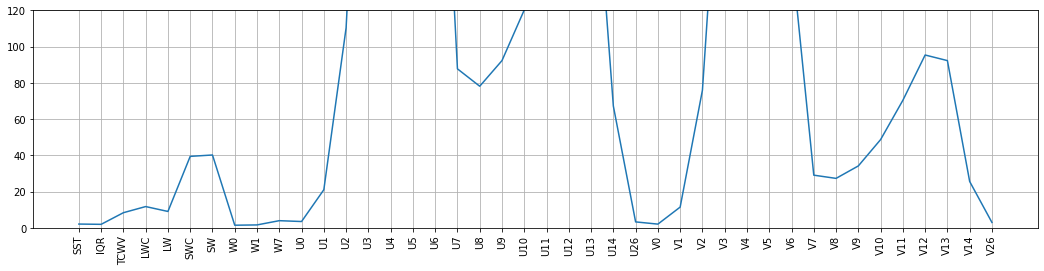

In [13]:
plt.figure(figsize = (18,4))
plt.plot(vif[1:])
plt.xticks(rotation = 90)
plt.ylim(0,120)
plt.grid()
plt.show()

# Test 2

In [14]:
### Creating column names
columna = ['SST','IQR','TCWV','LWC','LW','SWC','SW','W0','W1','W7',
           'U0','U1','U2','U7','U8','U9','U10','U14','U26','V0','V1','V2',
           'V7','V8','V9','V10','V11','V12','V13','V14','V26']
### Put them in a dataframe!
X = pd.DataFrame(np.column_stack((sst,iqr,tcw,LWc,LW,SWc,SW,ww[:,0],ww[:,1],ww[:,7],uu[:,0],
                                  uu[:,1],uu[:,2],uu[:,7],uu[:,8],uu[:,9],uu[:,10],uu[:,14],uu[:,26],
                                  vv[:,0],vv[:,1],vv[:,2],vv[:,7],vv[:,8],vv[:,9],vv[:,10],
                                  vv[:,11],vv[:,12],vv[:,13],vv[:,14],vv[:,26])), columns = columna)

In [15]:
##VIF
V = add_constant(X)
vif = pd.Series([variance_inflation_factor(V.values, i) for i in range(V.shape[1])], index=V.columns)

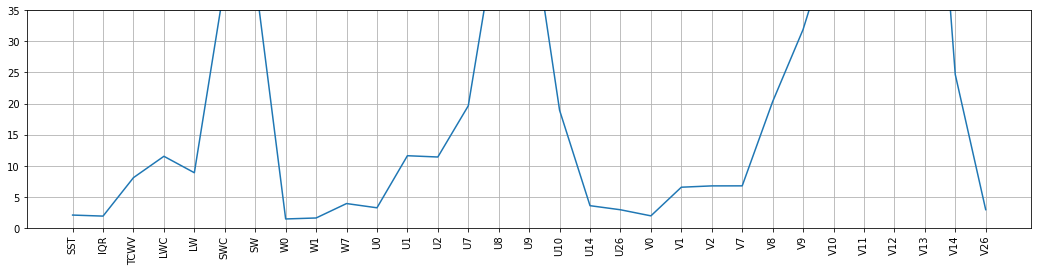

In [16]:
plt.figure(figsize = (18,4))
plt.plot(vif[1:])
plt.xticks(rotation = 90)
plt.ylim(0,35)
plt.grid()
plt.show()

# Test 3

In [17]:
### Creating column names
columna = ['SST','IQR','TCWV','LW','W0','W1','W7',
           'U0','U1','U4','U7','U11','U14','U26','V0','V1',
           'V4','V7','V9','V12','V14','V26']
### Put them in a dataframe!
X = pd.DataFrame(np.column_stack((sst,iqr,tcw,LW,ww[:,0],ww[:,1],ww[:,7],uu[:,0],
                                  uu[:,1],uu[:,4],uu[:,7],uu[:,11],uu[:,14],uu[:,26],vv[:,0],vv[:,1],
                                  vv[:,4],vv[:,7],vv[:,9],vv[:,12],vv[:,14],vv[:,26])), columns = columna)

In [18]:
##VIF
V = add_constant(X)
vif = pd.Series([variance_inflation_factor(V.values, i) for i in range(V.shape[1])], index=V.columns)

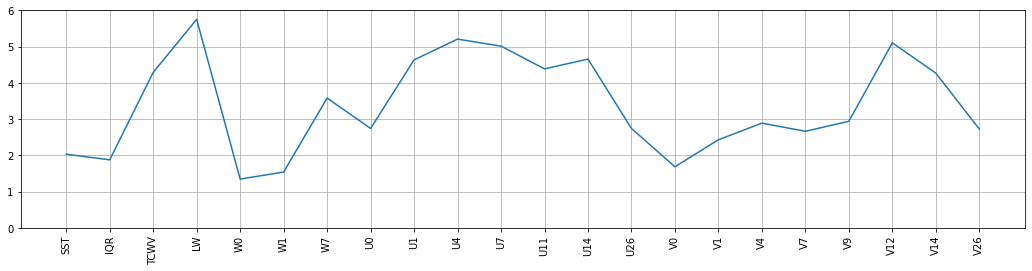

In [19]:
plt.figure(figsize = (18,4))
plt.plot(vif[1:])
plt.xticks(rotation = 90)
plt.ylim(0,6)
plt.grid()
plt.show()

In [20]:
### Create data!
#Creating column names
columna = ['Dates','SST','IQR','TCWV','LW','W0','W1','W7',
           'U0','U1','U4','U7','U11','U14','U26','V0','V1',
           'V4','V7','V9','V12','V14','V26']
### Put them in a dataframe!
X = pd.DataFrame(np.column_stack((slopes['Dates'][0:35040],sst,iqr,tcw,LW,ww[:,0],ww[:,1],ww[:,7],uu[:,0],
                                  uu[:,1],uu[:,4],uu[:,7],uu[:,11],uu[:,14],uu[:,26],vv[:,0],vv[:,1],
                                  vv[:,4],vv[:,7],vv[:,9],vv[:,12],vv[:,14],vv[:,26])), columns = columna)

In [21]:
X.to_csv(path+'Data_to_train.csv', index = False) 